In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path

# Load dataset
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


# Clean the price column
def clean_price(x):
    if pd.isna(x): return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data['Launched Price (India)'] = data['Launched Price (India)'].apply(clean_price)
data.rename(columns={'Launched Price (India)': 'Price_INR'}, inplace=True)


In [5]:
def extract_battery(x):
    if pd.isna(x):
        return None
    match = re.search(r'(\d+(\.\d+)?)', str(x).replace(',', ''))
    return float(match.group(1)) if match else None

data['Battery_mAh'] = data['Battery Capacity'].apply(extract_battery)


In [7]:
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)


C:\Users\guddi\AppData\Local\Temp\ipykernel_7140\1972717966.py:25: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\guddi\AppData\Local\Temp\ipykernel_7140\1972717966.py:26: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.savefig(out_dir / "price_vs_battery.png")
C:\Users\guddi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


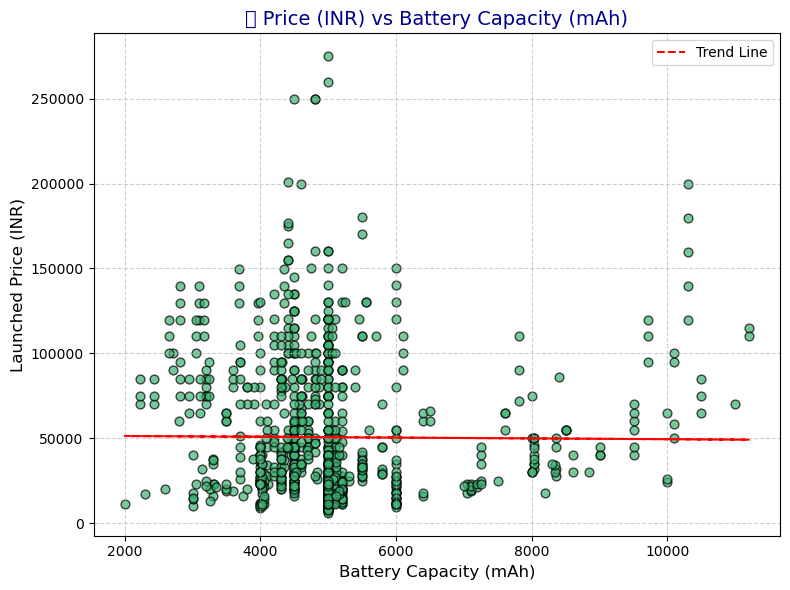

In [9]:
plt.figure(figsize=(8,6))
subset2 = data.dropna(subset=['Price_INR','Battery_mAh'])

# Scatter plot
plt.scatter(
    subset2['Battery_mAh'],
    subset2['Price_INR'],
    s=40,
    c='mediumseagreen',
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Battery Capacity (mAh)', fontsize=12)
plt.ylabel('Launched Price (INR)', fontsize=12)
plt.title('🔋 Price (INR) vs Battery Capacity (mAh)', fontsize=14, color='darkblue')
plt.grid(True, linestyle='--', alpha=0.6)

# Add a trend line
z = np.polyfit(subset2['Battery_mAh'], subset2['Price_INR'], 1)
p = np.poly1d(z)
plt.plot(subset2['Battery_mAh'], p(subset2['Battery_mAh']), color='red', linestyle='--', label='Trend Line')
plt.legend()

plt.tight_layout()
plt.savefig(out_dir / "price_vs_battery.png")
plt.show()


### Box Plot — Compare Price Distribution Across Battery Groups

###### Helps you see which battery ranges correspond to high-end phones.

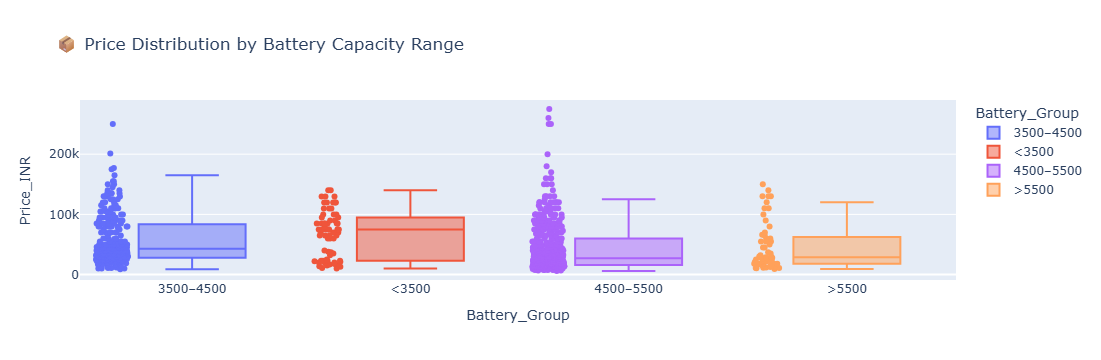

In [19]:
import pandas as pd
import plotly.express as px

# Create battery range groups
bins = [0, 3500, 4500, 5500, 7000]
labels = ['<3500', '3500–4500', '4500–5500', '>5500']
data['Battery_Group'] = pd.cut(data['Battery_mAh'], bins=bins, labels=labels, include_lowest=True)

fig = px.box(
    data,
    x='Battery_Group',
    y='Price_INR',
    color='Battery_Group',
    title='📦 Price Distribution by Battery Capacity Range',
    points='all'
)
fig.show()
